In [1]:
# https://www.kaggle.com/datasets/thembatman/make-moons-from-sklearn
# Make moons from sklearn
# make_moons.csv

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

In [4]:
dataset = pd.read_csv('make_moons.csv')
print("Первые 5 строк:")
print(dataset.head())

Первые 5 строк:
          X         Y  label
0 -1.129064 -0.049047      0
1  0.264658  0.960315      0
2  0.604729  0.585562      0
3 -0.603916  0.789943      0
4 -0.591466  0.712346      0


In [6]:
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
def plot_decision_boundary(X, y, model, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.RdYlBu)
    plt.title(title)
    plt.xlabel("Признак 1")
    plt.ylabel("Признак 2")

In [10]:
mlp_base = MLPClassifier(hidden_layer_sizes=(10,), activation='relu', max_iter=1000, random_state=42)
mlp_base.fit(X_train_scaled, y_train)
y_pred_base = mlp_base.predict(X_test_scaled)
acc_base = accuracy_score(y_test, y_pred_base)
print(f"Точность базовой модели: {acc_base:.3f}")

Точность базовой модели: 0.993


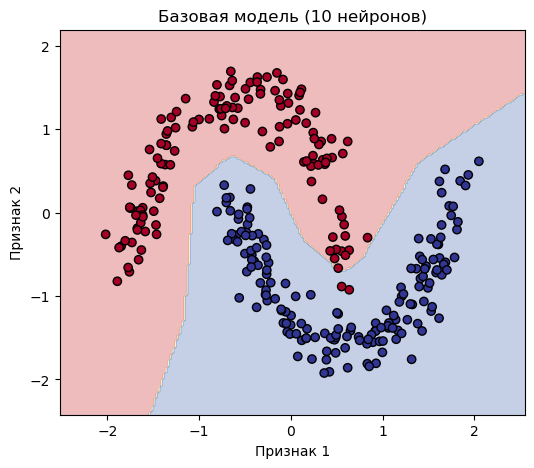

In [11]:
plt.figure(figsize=(6, 5))
plot_decision_boundary(X_test_scaled, y_test, mlp_base, "Базовая модель (10 нейронов)")
plt.show()

In [12]:
architectures = [
    (5,),        # один слой, 5 нейронов
    (10,),       # один слой, 10 нейронов
    (20,),       # один слой, 20 нейронов
    (10, 5),     # два слоя: 10 и 5 нейронов
    (20, 10)     # два слоя: 20 и 10 нейронов
]

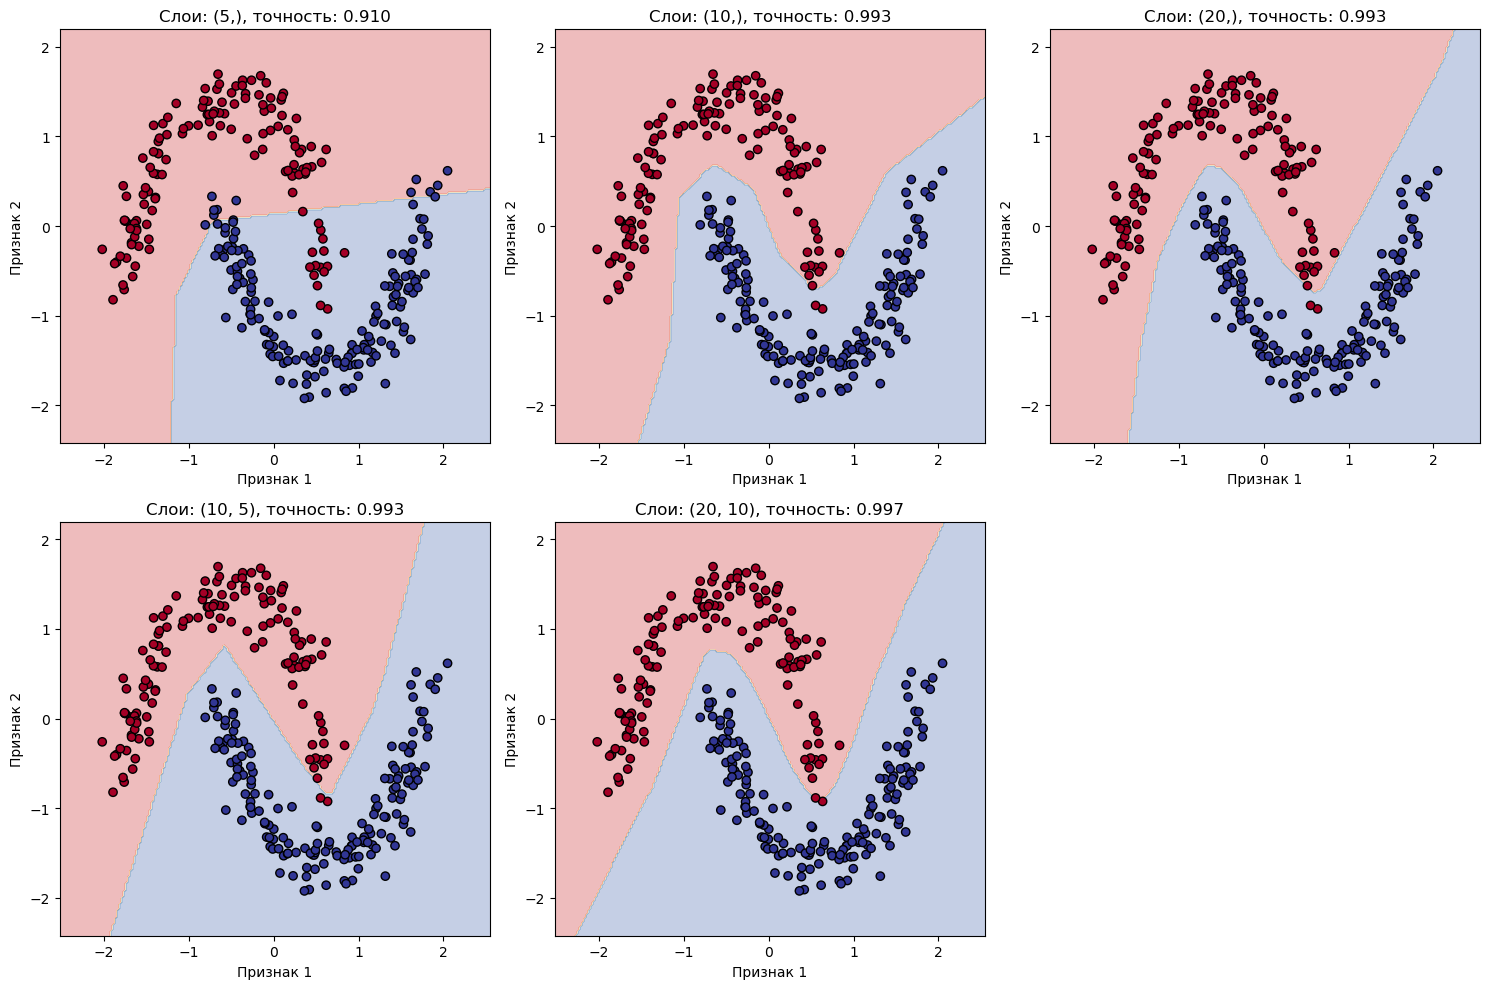

In [13]:
plt.figure(figsize=(15, 10))
for i, arch in enumerate(architectures, 1):
    mlp = MLPClassifier(hidden_layer_sizes=arch, activation='relu', max_iter=1000, random_state=42)
    mlp.fit(X_train_scaled, y_train)
    plt.subplot(2, 3, i)
    plot_decision_boundary(X_test_scaled, y_test, mlp, f"Слои: {arch}")
    acc = accuracy_score(y_test, mlp.predict(X_test_scaled))
    plt.title(f"Слои: {arch}, точность: {acc:.3f}")
plt.tight_layout()
plt.show()

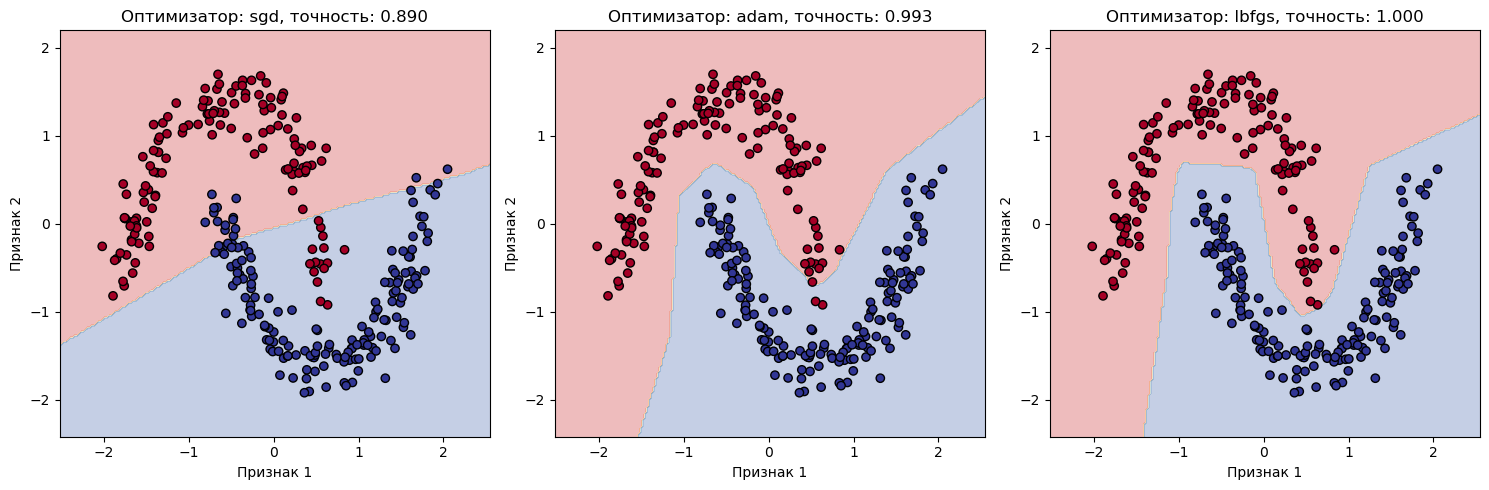

In [14]:
optimizers = ['sgd', 'adam', 'lbfgs']
plt.figure(figsize=(15, 5))
for i, solver in enumerate(optimizers, 1):
    mlp = MLPClassifier(hidden_layer_sizes=(10,), activation='relu', solver=solver, max_iter=1000, random_state=42)
    mlp.fit(X_train_scaled, y_train)
    plt.subplot(1, 3, i)
    plot_decision_boundary(X_test_scaled, y_test, mlp, f"Оптимизатор: {solver}")
    acc = accuracy_score(y_test, mlp.predict(X_test_scaled))
    plt.title(f"Оптимизатор: {solver}, точность: {acc:.3f}")
plt.tight_layout()
plt.show()